In [1]:
pip install google-cloud-bigquery pandas

   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/4.9 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.9 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.9 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.9 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.9 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.9 MB ? eta -:--:--
   -- ------------------------------------- 0.3/4.9 MB ? eta -:--:--
   ---- ----------------------------------- 0.5/4.9 MB 215.9 kB/s eta 0:00:21
   ---- -----------------

In [4]:
pip install db-dtypes


Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install google-cloud-bigquery pandas pyarrow

Note: you may need to restart the kernel to use updated packages.


In [32]:
from google.cloud import bigquery

client = bigquery.Client(project="gdelt-hackathon16")

query = """
SELECT *
FROM `gdelt-bq.gdeltv2.events`
WHERE
    ActionGeo_CountryCode = 'BN'
    AND SQLDATE >= CAST(
        FORMAT_DATE('%Y%m%d',
            DATE_SUB(CURRENT_DATE(), INTERVAL 12 MONTH)
        ) AS INT64
    )
LIMIT 3000
"""


df_benin = client.query(query).to_dataframe()

print(df_benin.head())
print("Dimensions :", df_benin.shape)

Forbidden: 403 Quota exceeded: Your project exceeded quota for free query bytes scanned. For more information, see https://cloud.google.com/bigquery/docs/troubleshoot-quotas; reason: quotaExceeded, location: unbilled.analysis, message: Quota exceeded: Your project exceeded quota for free query bytes scanned. For more information, see https://cloud.google.com/bigquery/docs/troubleshoot-quotas

Location: US
Job ID: b2af356b-4fd8-449f-a721-8528092c690e


In [6]:
df_benin["ActionGeo_CountryCode"].unique()

array(['BN'], dtype=object)

In [29]:
query = """
SELECT *
SELECT *
FROM `gdelt-bq.gdeltv2.events`
WHERE
    ActionGeo_CountryCode = 'BN'
    AND SQLDATE >= FORMAT_DATE('%Y%m%d', DATE_SUB(CURRENT_DATE(), INTERVAL 12 MONTH))
LIMIT 50000
"""

df_benin = client.query(query).to_dataframe()

print(df_benin.shape)


BadRequest: 400 Syntax error: Expected end of input but got keyword SELECT at [3:1]; reason: invalidQuery, location: query, message: Syntax error: Expected end of input but got keyword SELECT at [3:1]

Location: US
Job ID: d96d8ec2-2bb2-46bf-9e37-d5a9d348f0ad


In [8]:
print(df_benin.head())
print("Dimensions :", df_benin.shape)

   GLOBALEVENTID   SQLDATE  MonthYear  Year  FractionDate Actor1Code  \
0     1281862611  20260102     202601  2026     2026.0055        NGA   
1     1281832949  20260102     202601  2026     2026.0055        CVL   
2     1281832975  20260102     202601  2026     2026.0055        CVL   
3     1281839157  20260102     202601  2026     2026.0055        CVL   
4     1281817410  20260101     202601  2026     2026.0027        ZWE   

     Actor1Name Actor1CountryCode Actor1KnownGroupCode Actor1EthnicCode  ...  \
0       NIGERIA               NGA                 None             None  ...   
1       CITIZEN              None                 None             None  ...   
2       CITIZEN              None                 None             None  ...   
3  NEIGHBORHOOD              None                 None             None  ...   
4      ZIMBABWE               ZWE                 None             None  ...   

  ActionGeo_Type ActionGeo_FullName ActionGeo_CountryCode ActionGeo_ADM1Code  \
0     

In [9]:
df_benin.to_excel("benin_gdelt.xlsx", index=False)

In [11]:
df_benin[df_benin["GoldsteinScale"] < 0]

,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1281862611,20260102,202601,2026,2026.0055,NGA,NIGERIA,NGA,None,None,...,1,Benin,BN,BN,None,9.50000,2.25000,BN,20260102080000,https://theeagleonline.com.ng/aisha-yesufu-fro...
2,1281832975,20260102,202601,2026,2026.0055,CVL,CITIZEN,None,None,None,...,1,Benin,BN,BN,None,9.50000,2.25000,BN,20260102000000,https://punchng.com/from-benin-to-ilorin-the-n...
4,1281817410,20260101,202601,2026,2026.0027,ZWE,ZIMBABWE,ZWE,None,None,...,1,Benin,BN,BN,None,9.50000,2.25000,BN,20260101184500,https://eahelqesa.com/news/%D8%AA%D8%A7%D8%B1%...
6,1281840553,20260102,202601,2026,2026.0055,CRM,CULPRIT,None,None,None,...,1,Benin,BN,BN,None,9.50000,2.25000,BN,20260102014500,https://punchng.com/obasekis-ally-house-burnt-...
7,1281868867,20260102,202601,2026,2026.0055,MED,MEDIA,None,None,None,...,1,Benin,BN,BN,None,9.50000,2.25000,BN,20260102090000,https://www.lahaine.org/mundo.php/evaluacion-y...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9981,1224380730,20250203,202502,2025,2025.0904,MIL,MILITARY,None,None,None,...,1,Benin,BN,BN,None,9.50000,2.25000,BN,20250203203000,https://levenementprecis.com/soutien-aux-victi...
9984,1224387239,20250203,202502,2025,2025.0904,NGA,NIGERIA,NGA,None,None,...,4,"Lokoja, Kogi, Nigeria",NI,NI41,22902,7.80236,6.74300,-2017876,20250203213000,https://blueprint.ng/fg-okays-%E2%82%A61-334tr...
9985,1224387240,20250203,202502,2025,2025.0904,NGA,NIGERIA,NGA,None,None,...,4,"Obajana, Kogi, Nigeria",NI,NI41,22905,7.91667,6.43333,-2021454,20250203213000,https://blueprint.ng/fg-okays-%E2%82%A61-334tr...
9987,1224323165,20250203,202502,2025,2025.0904,GBR,BRITISH,GBR,None,None,...,4,"Parthenon, Perifereia Kentrikis Makedonias, Gr...",GR,GR59,16697,40.11670,23.81670,-825722,20250203150000,https://capitalethiopia.com/2025/02/03/young-a...


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# ── Convertir les dates ──────────────────────────────────────────
df_benin['date']     = pd.to_datetime(df_benin['SQLDATE'].astype(str), format='%Y%m%d')
df_benin['mois']     = df_benin['date'].dt.to_period('M').astype(str)
df_benin['semaine']  = df_benin['date'].dt.isocalendar().week.astype(int)

# ── Labels CAMEO lisibles ────────────────────────────────────────
cameo = {
    '01':'Déclarations publiques', '02':'Appels / demandes',
    '03':'Expressions d intention', '04':'Consultations',
    '05':'Engagement diplomatique', '06':'Coopération matérielle',
    '07':'Aide fournie',            '08':'Céder / coopérer',
    '09':'Médiation',               '10':'Demandes',
    '11':'Désapprobation',          '12':'Rejet',
    '13':'Menace',                  '14':'Protestation',
    '15':'Coercition',              '16':'Attaque militaire',
    '17':'Violence',                '18':'Assaut',
    '19':'Violence de masse',       '20':'Usage de la force'
}
df_benin['categorie'] = df_benin['EventRootCode'].astype(str).map(cameo).fillna('Autre')

# ── Classifier le ton ────────────────────────────────────────────
df_benin['ton_label'] = pd.cut(
    df_benin['AvgTone'],
    bins=[-100, -5, -1, 1, 5, 100],
    labels=['Très négatif','Négatif','Neutre','Positif','Très positif']
)

# ── Dataset geo uniquement ───────────────────────────────────────
df_geo = df_benin.dropna(subset=['ActionGeo_Lat','ActionGeo_Long']).copy()

print(f"✅ {len(df_benin):,} événements | Période : {df_benin['date'].min().date()} → {df_benin['date'].max().date()}")
print(f"   Avec GPS : {len(df_geo):,} lignes")
df_benin.head(3)


✅ 47 événements | Période : 2025-01-01 → 2025-04-28
   Avec GPS : 47 lignes


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,...,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL,date,mois,semaine,categorie,ton_label
0,1218419766,20250101,202501,2025,2025.0027,BEN,BENIN,BEN,NaN,NaN,...,9.5,2.25,BN,20250101120000,https://guardian.ng/news/benin-republic-protes...,2025-01-01,2025-01,1,Autre,Négatif
1,1218419967,20250101,202501,2025,2025.0027,GOV,DIPLOMAT,NaN,NaN,NaN,...,9.5,2.25,BN,20250101120000,https://guardian.ng/news/benin-republic-protes...,2025-01-01,2025-01,1,Autre,Négatif
2,1218419971,20250101,202501,2025,2025.0027,GOV,DIPLOMAT,NaN,NaN,NaN,...,9.5,2.25,BN,20250101120000,https://guardian.ng/news/benin-republic-protes...,2025-01-01,2025-01,1,Autre,Négatif


In [25]:

print("=" * 60)
print("📊 ANALYSE COMPLÈTE DES COLONNES GDELT — BÉNIN")
print("=" * 60)

cols_info = {
    "🗓️  Temporelles":   ['SQLDATE', 'MonthYear', 'Year', 'FractionDate'],
    "🧑  Acteur 1":      ['Actor1Code','Actor1Name','Actor1CountryCode',
                          'Actor1Type1Code','Actor1Religion1Code','Actor1EthnicCode'],
    "🧑  Acteur 2":      ['Actor2Code','Actor2Name','Actor2CountryCode',
                          'Actor2Type1Code','Actor2Religion1Code','Actor2EthnicCode'],
    "⚡  Événement":     ['EventCode','EventBaseCode','EventRootCode',
                          'QuadClass','GoldsteinScale','IsRootEvent'],
    "📰  Médias":        ['NumMentions','NumSources','NumArticles','AvgTone'],
    "📍  Géo Acteur 1":  ['Actor1Geo_Type','Actor1Geo_FullName',
                          'Actor1Geo_CountryCode','Actor1Geo_Lat','Actor1Geo_Long'],
    "📍  Géo Acteur 2":  ['Actor2Geo_Type','Actor2Geo_FullName',
                          'Actor2Geo_CountryCode','Actor2Geo_Lat','Actor2Geo_Long'],
    "📍  Géo Action":    ['ActionGeo_Type','ActionGeo_FullName',
                          'ActionGeo_CountryCode','ActionGeo_Lat','ActionGeo_Long'],
    "🔗  Source":        ['DATEADDED','SOURCEURL'],
}

for groupe, cols in cols_info.items():
    print(f"\n{groupe}")
    for c in cols:
        if c in df_benin.columns:
            non_null = df_benin[c].notna().sum()
            pct = non_null / len(df_benin) * 100
            uniques = df_benin[c].nunique()
            bar = "█" * int(pct / 10) + "░" * (10 - int(pct / 10))
            print(f"  {c:<30} [{bar}] {pct:5.1f}%  ({uniques} valeurs uniques)")

📊 ANALYSE COMPLÈTE DES COLONNES GDELT — BÉNIN

🗓️  Temporelles
  SQLDATE                        [██████████] 100.0%  (18 valeurs uniques)
  MonthYear                      [██████████] 100.0%  (4 valeurs uniques)
  Year                           [██████████] 100.0%  (1 valeurs uniques)
  FractionDate                   [██████████] 100.0%  (18 valeurs uniques)

🧑  Acteur 1
  Actor1Code                     [████████░░]  80.9%  (14 valeurs uniques)
  Actor1Name                     [████████░░]  80.9%  (19 valeurs uniques)
  Actor1CountryCode              [████░░░░░░]  44.7%  (6 valeurs uniques)
  Actor1Type1Code                [████░░░░░░]  48.9%  (6 valeurs uniques)
  Actor1Religion1Code            [░░░░░░░░░░]   0.0%  (0 valeurs uniques)
  Actor1EthnicCode               [░░░░░░░░░░]   0.0%  (0 valeurs uniques)

🧑  Acteur 2
  Actor2Code                     [██████░░░░]  66.0%  (15 valeurs uniques)
  Actor2Name                     [██████░░░░]  66.0%  (19 valeurs uniques)
  Actor2CountryCo

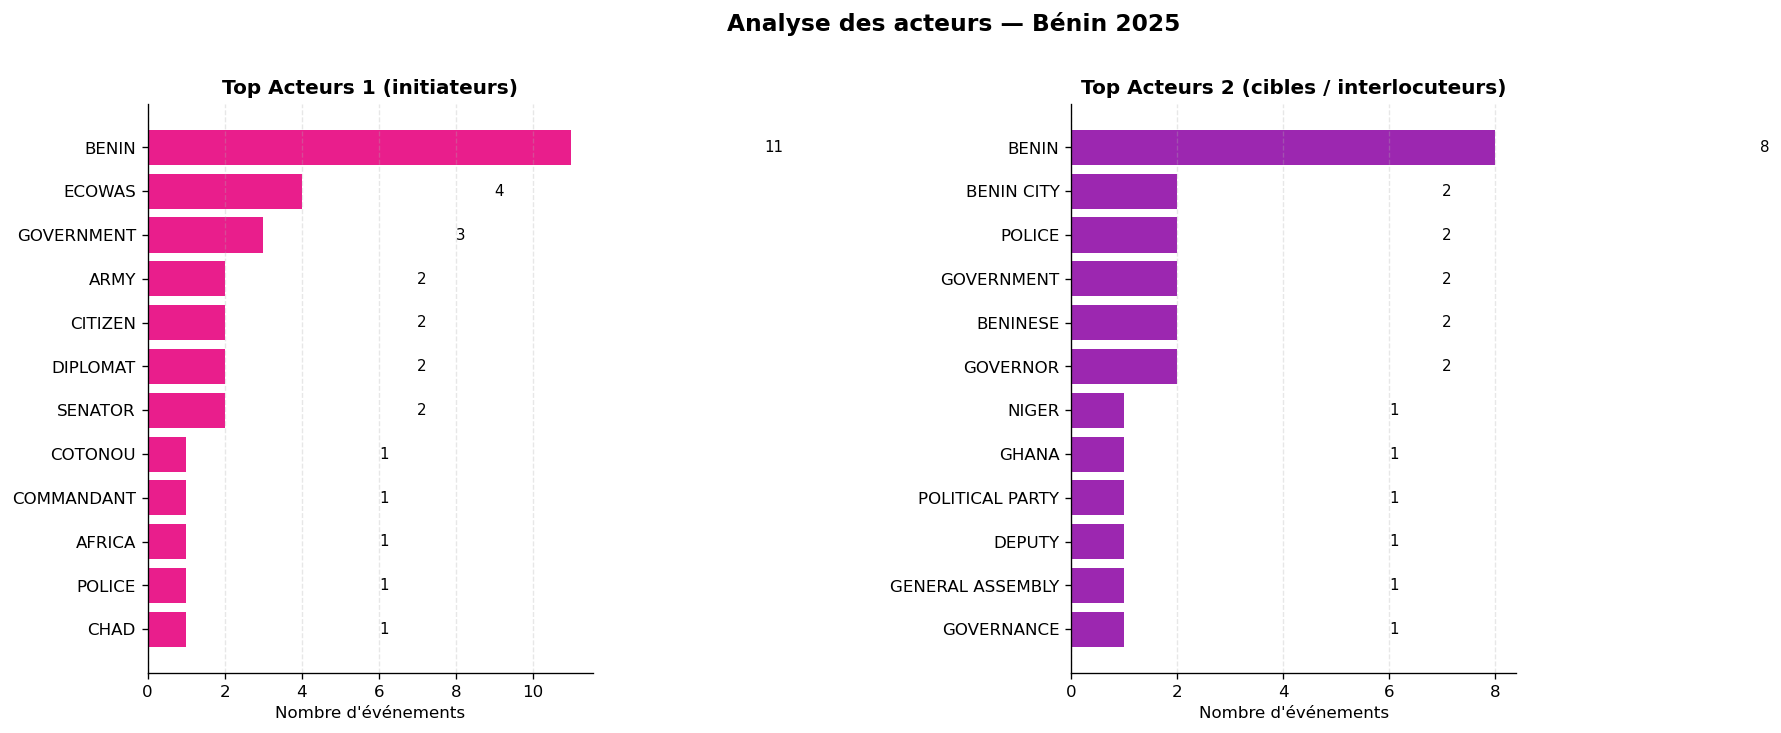

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Acteurs 1 les plus fréquents
top_a1 = df_benin['Actor1Name'].dropna().value_counts().head(12)
axes[0].barh(top_a1.index[::-1], top_a1.values[::-1], color='#E91E8C')
axes[0].set_title('Top Acteurs 1 (initiateurs)', fontweight='bold')
axes[0].set_xlabel('Nombre d\'événements')
for i, v in enumerate(top_a1.values[::-1]):
    axes[0].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

# Acteurs 2 les plus fréquents
top_a2 = df_benin['Actor2Name'].dropna().value_counts().head(12)
axes[1].barh(top_a2.index[::-1], top_a2.values[::-1], color='#9C27B0')
axes[1].set_title('Top Acteurs 2 (cibles / interlocuteurs)', fontweight='bold')
axes[1].set_xlabel('Nombre d\'événements')
for i, v in enumerate(top_a2.values[::-1]):
    axes[1].text(v + 5, i, f'{v:,}', va='center', fontsize=9)

for ax in axes:
    ax.spines[['top','right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('Analyse des acteurs — Bénin 2025', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('acteurs_analyse.png', bbox_inches='tight')
plt.show()

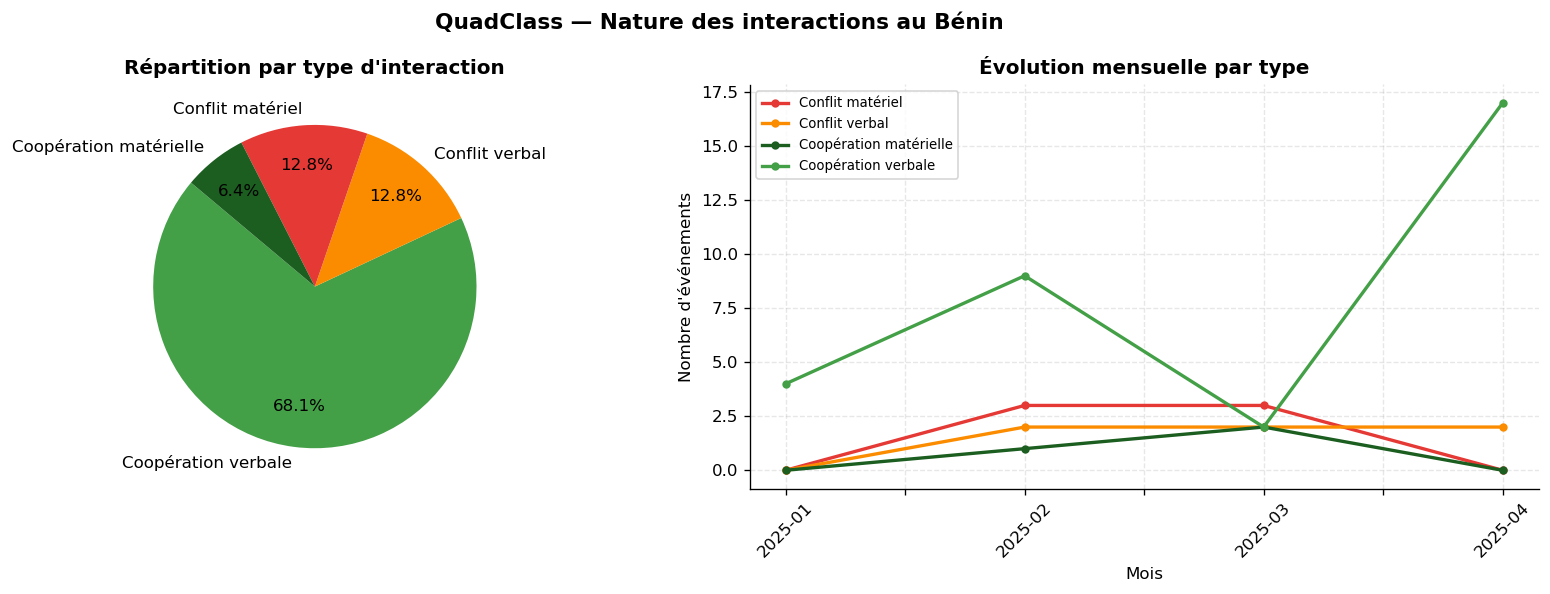


📊 Résumé : 35 événements coopératifs (74.5%) vs 12 conflictuels (25.5%)


In [27]:
quad_labels = {
    1: 'Coopération verbale',
    2: 'Coopération matérielle',
    3: 'Conflit verbal',
    4: 'Conflit matériel'
}
df_benin['QuadClass_label'] = df_benin['QuadClass'].map(quad_labels)

quad_colors = {
    'Coopération verbale':    '#43A047',
    'Coopération matérielle': '#1B5E20',
    'Conflit verbal':         '#FB8C00',
    'Conflit matériel':       '#E53935'
}

counts = df_benin['QuadClass_label'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Camembert
colors_pie = [quad_colors.get(l, '#ccc') for l in counts.index]
wedges, texts, autotexts = ax1.pie(
    counts.values, labels=counts.index,
    colors=colors_pie, autopct='%1.1f%%',
    startangle=140, pctdistance=0.75
)
for t in autotexts: t.set_fontsize(10)
ax1.set_title('Répartition par type d\'interaction', fontweight='bold')

# Évolution mensuelle par QuadClass
quad_mois = df_benin.groupby(['mois','QuadClass_label']).size().unstack(fill_value=0)
quad_mois.plot(ax=ax2, color=[quad_colors.get(c,'#ccc') for c in quad_mois.columns],
               linewidth=2, marker='o', markersize=4)
ax2.set_title('Évolution mensuelle par type', fontweight='bold')
ax2.set_xlabel('Mois'); ax2.set_ylabel('Nombre d\'événements')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(alpha=0.3, linestyle='--')
ax2.spines[['top','right']].set_visible(False)
ax2.legend(fontsize=8, loc='upper left')

plt.suptitle('QuadClass — Nature des interactions au Bénin', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('quadclass_analyse.png', bbox_inches='tight')
plt.show()

# Résumé
coop = counts.get('Coopération verbale',0) + counts.get('Coopération matérielle',0)
conf = counts.get('Conflit verbal',0) + counts.get('Conflit matériel',0)
print(f"\n📊 Résumé : {coop:,} événements coopératifs ({coop/(coop+conf)*100:.1f}%) "
      f"vs {conf:,} conflictuels ({conf/(coop+conf)*100:.1f}%)")

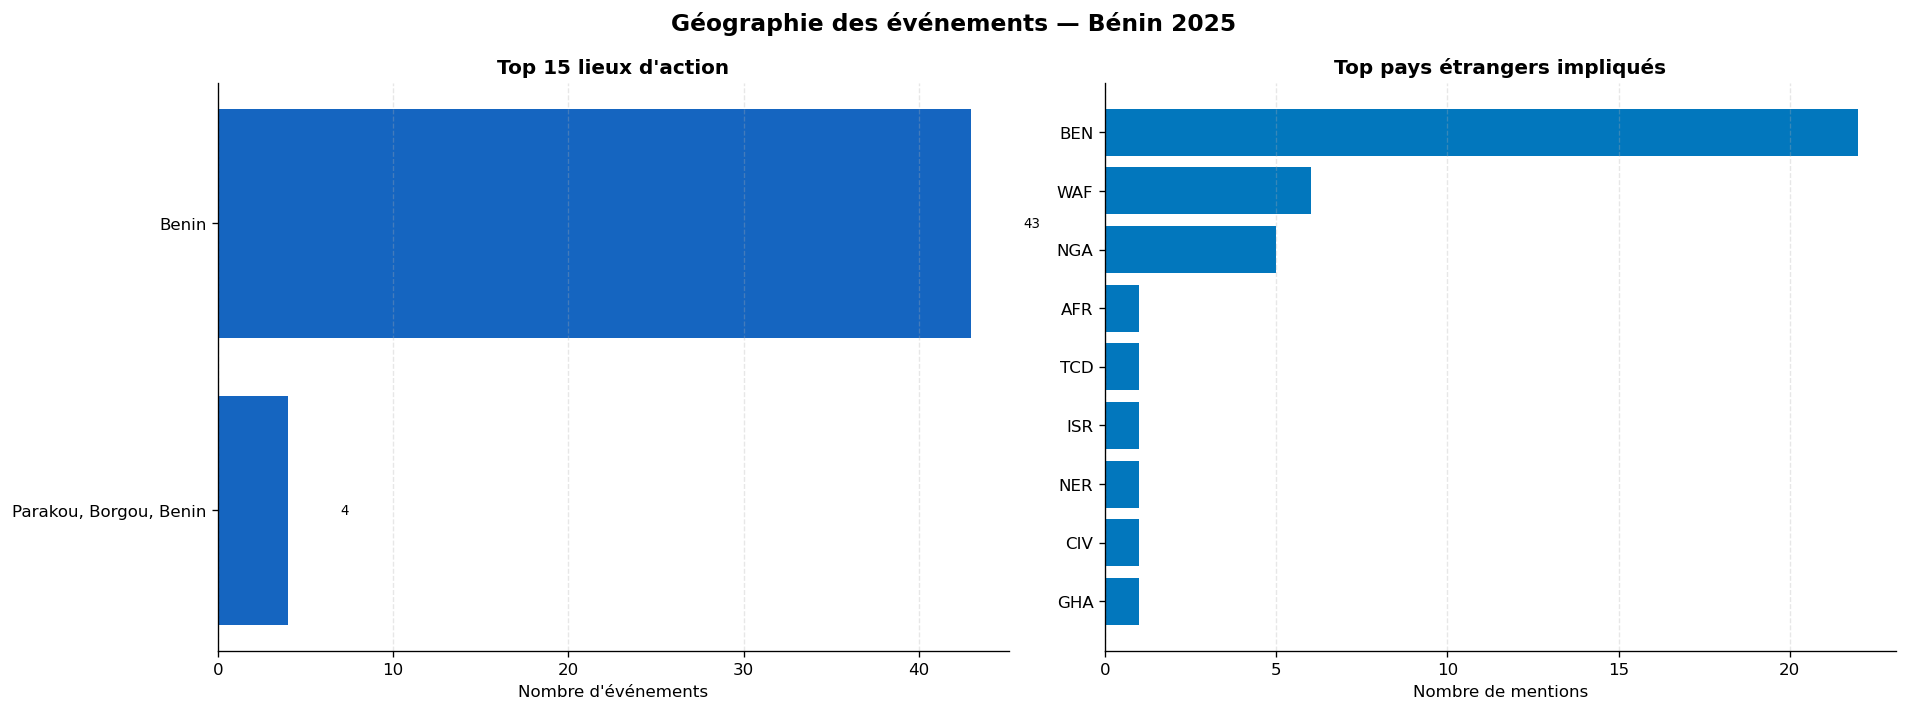

In [33]:
# Top lieux d'action
top_lieux = df_benin['ActionGeo_FullName'].dropna().value_counts().head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top lieux
axes[0].barh(top_lieux.index[::-1], top_lieux.values[::-1], color='#1565C0')
axes[0].set_title('Top 15 lieux d\'action', fontweight='bold')
axes[0].set_xlabel('Nombre d\'événements')
axes[0].spines[['top','right']].set_visible(False)
axes[0].grid(axis='x', alpha=0.3, linestyle='--')
for i, v in enumerate(top_lieux.values[::-1]):
    axes[0].text(v + 3, i, f'{v:,}', va='center', fontsize=8)

# Pays d'origine des acteurs étrangers impliqués
pays_acteurs = pd.concat([
    df_benin['Actor1CountryCode'].dropna(),
    df_benin['Actor2CountryCode'].dropna()
]).value_counts().head(15)

axes[1].barh(pays_acteurs.index[::-1], pays_acteurs.values[::-1], color='#0277BD')
axes[1].set_title('Top pays étrangers impliqués', fontweight='bold')
axes[1].set_xlabel('Nombre de mentions')
axes[1].spines[['top','right']].set_visible(False)
axes[1].grid(axis='x', alpha=0.3, linestyle='--')

plt.suptitle('Géographie des événements — Bénin 2025', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('geographie_analyse.png', bbox_inches='tight')
plt.show()

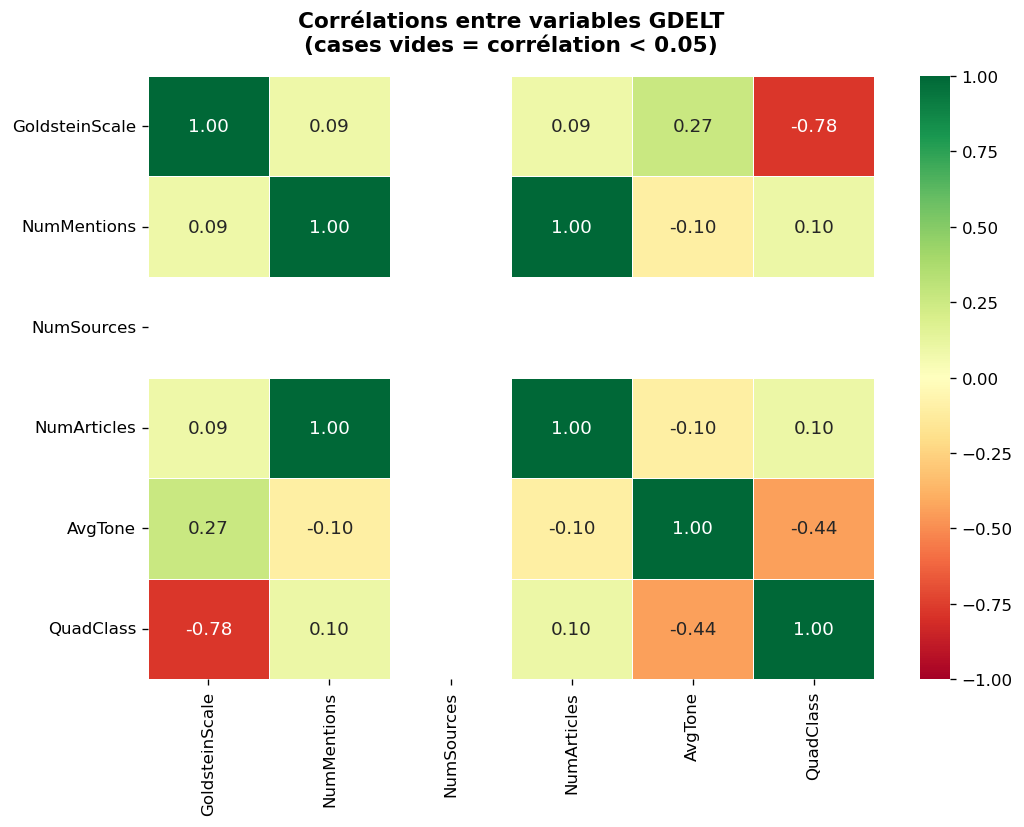


💡 Interprétation rapide :
   GoldsteinScale ↔ QuadClass  : -0.78 (+ = coopération)
   AvgTone ↔ GoldsteinScale    : 0.27
   NumArticles ↔ NumMentions   : 1.00


In [34]:
vars_num = ['GoldsteinScale','NumMentions','NumSources','NumArticles',
            'AvgTone','QuadClass']
df_corr = df_benin[vars_num].dropna()

fig, ax = plt.subplots(figsize=(9, 7))
corr = df_corr.corr()
mask = corr.abs() < 0.05  # Masquer les corrélations très faibles

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1,
            linewidths=0.5, ax=ax, mask=mask,
            annot_kws={'size': 11})
ax.set_title('Corrélations entre variables GDELT\n(cases vides = corrélation < 0.05)',
             fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('correlations.png', bbox_inches='tight')
plt.show()

print("\n💡 Interprétation rapide :")
print(f"   GoldsteinScale ↔ QuadClass  : {corr.loc['GoldsteinScale','QuadClass']:.2f} (+ = coopération)")
print(f"   AvgTone ↔ GoldsteinScale    : {corr.loc['AvgTone','GoldsteinScale']:.2f}")
print(f"   NumArticles ↔ NumMentions   : {corr.loc['NumArticles','NumMentions']:.2f}")

In [35]:
print("=" * 65)
print("📋 RÉSUMÉ EXÉCUTIF — DONNÉES GDELT BÉNIN 2025")
print("=" * 65)

print(f"\n🔢  Volume total         : {len(df_benin):,} événements")
print(f"📅  Période              : {df_benin['date'].min().date()} → {df_benin['date'].max().date()}")
print(f"🏙️  Lieux uniques        : {df_benin['ActionGeo_FullName'].nunique()} zones d'action")
print(f"👥  Acteurs uniques      : {df_benin['Actor1Name'].nunique()} acteurs différents")

print(f"\n📌  Type d'événement dominant : {df_benin['categorie'].value_counts().index[0]}")
print(f"     ({df_benin['categorie'].value_counts().iloc[0]/len(df_benin)*100:.1f}% des événements)")

print(f"\n📰  Couverture médiatique")
print(f"     Ton moyen          : {df_benin['AvgTone'].mean():.2f} ({'⚠️ Négatif' if df_benin['AvgTone'].mean() < 0 else '✅ Positif'})")
print(f"     Médiane articles   : {df_benin['NumArticles'].median():.0f} articles / événement")
print(f"     Événement le + couvert : {df_benin['NumArticles'].max()} articles")

print(f"\n⚖️   Stabilité globale")
print(f"     Score Goldstein moyen : {df_benin['GoldsteinScale'].mean():.2f}")
print(f"     (de -10 = très déstabilisant à +10 = très coopératif)")

mois_chaud = df_benin.groupby('mois').size().idxmax()
print(f"\n🔥  Mois le plus actif  : {mois_chaud} ({df_benin.groupby('mois').size().max():,} événements)")

import os; os.makedirs('data', exist_ok=True)
df_benin.to_csv('data/benin_gdelt_clean.csv', index=False)
print(f"\n✅  Données sauvegardées → data/benin_gdelt_clean.csv")
print("=" * 65)

📋 RÉSUMÉ EXÉCUTIF — DONNÉES GDELT BÉNIN 2025

🔢  Volume total         : 47 événements
📅  Période              : 2025-01-01 → 2025-04-28
🏙️  Lieux uniques        : 2 zones d'action
👥  Acteurs uniques      : 19 acteurs différents

📌  Type d'événement dominant : Autre
     (74.5% des événements)

📰  Couverture médiatique
     Ton moyen          : -0.60 (⚠️ Négatif)
     Médiane articles   : 5 articles / événement
     Événement le + couvert : 10 articles

⚖️   Stabilité globale
     Score Goldstein moyen : 0.14
     (de -10 = très déstabilisant à +10 = très coopératif)

🔥  Mois le plus actif  : 2025-04 (19 événements)

✅  Données sauvegardées → data/benin_gdelt_clean.csv


##  Cellule 1 — Préparation des données pour la classification

In [36]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120

# ── Charger les données ─────────────────────────────────────────
# Si tu as le CSV local :
# df_benin = pd.read_csv('data/benin_gdelt_2025_clean.csv')
# Sinon on utilise df_benin déjà en mémoire

# ── Créer la variable cible : Conflit vs Coopération ───────────
# QuadClass : 1-2 = Coopération | 3-4 = Conflit
# GoldsteinScale : négatif = déstabilisant, positif = coopératif

df_model = df_benin.copy()

# Variable cible binaire
df_model['cible'] = df_model['QuadClass'].apply(
    lambda x: 'Conflit' if x in [3, 4] else 'Coopération'
)

# Vérifier la distribution
print("=" * 50)
print("📊 Distribution de la variable cible :")
print("=" * 50)
dist = df_model['cible'].value_counts()
for label, count in dist.items():
    pct = count / len(df_model) * 100
    bar = "█" * int(pct / 5)
    print(f"  {label:<15} {count:>5} ({pct:.1f}%)  {bar}")

print(f"\n✅ Dataset prêt : {len(df_model):,} événements")

📊 Distribution de la variable cible :
  Coopération        35 (74.5%)  ██████████████
  Conflit            12 (25.5%)  █████

✅ Dataset prêt : 47 événements


In [38]:
# ── Variables numériques disponibles ───────────────────────────
features_num = ['GoldsteinScale', 'NumMentions', 'NumSources',
                'NumArticles', 'AvgTone']

# ── Encoder le type d'acteur (catégorielle → numérique) ────────
for col in ['Actor1Type1Code', 'Actor2Type1Code', 'EventRootCode']:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col + '_enc'] = le.fit_transform(
            df_model[col].fillna('UNKNOWN').astype(str)
        )
        features_num.append(col + '_enc')

# ── Encoder le pays d'origine des acteurs ──────────────────────
for col in ['Actor1CountryCode', 'Actor2CountryCode']:
    if col in df_model.columns:
        le = LabelEncoder()
        df_model[col + '_enc'] = le.fit_transform(
            df_model[col].fillna('UNKNOWN').astype(str)
        )
        features_num.append(col + '_enc')

# ── Nettoyer : supprimer les lignes avec valeurs manquantes ────
df_clean = df_model[features_num + ['cible']].dropna()
print(f"✅ Après nettoyage : {len(df_clean):,} lignes / {len(features_num)} features")

# ── Vérifier qu'on a assez de données ──────────────────────────
assert len(df_clean) >= 40, "❌ Pas assez de données ! Télécharge plus de fichiers GDELT."

# ── Afficher les features retenues ─────────────────────────────
print("\n📋 Features utilisées pour la classification :")
for i, f in enumerate(features_num, 1):
    print(f"   {i:2}. {f}")

✅ Après nettoyage : 47 lignes / 10 features

📋 Features utilisées pour la classification :
    1. GoldsteinScale
    2. NumMentions
    3. NumSources
    4. NumArticles
    5. AvgTone
    6. Actor1Type1Code_enc
    7. Actor2Type1Code_enc
    8. EventRootCode_enc
    9. Actor1CountryCode_enc
   10. Actor2CountryCode_enc


In [39]:
# ── Split train / test ─────────────────────────────────────────
X = df_clean[features_num]
y = df_clean['cible']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Normalisation ──────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"📐 Train : {len(X_train):,} | Test : {len(X_test):,}")
print(f"   Conflits  test : {(y_test=='Conflit').sum():,}")
print(f"   Coopérations test : {(y_test=='Coopération').sum():,}\n")

# ── Définir les 3 modèles ──────────────────────────────────────
modeles = {
    'Régression Logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':     GradientBoostingClassifier(n_estimators=100, random_state=42),
}

resultats = {}

print("⏳ Entraînement des modèles...")
print("=" * 55)

for nom, modele in modeles.items():
    # Entraîner
    if nom == 'Régression Logistique':
        modele.fit(X_train_sc, y_train)
        y_pred = modele.predict(X_test_sc)
        y_proba = modele.predict_proba(X_test_sc)[:, 1]
    else:
        modele.fit(X_train, y_train)
        y_pred  = modele.predict(X_test)
        y_proba = modele.predict_proba(X_test)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    resultats[nom] = {
        'modele': modele, 'y_pred': y_pred,
        'y_proba': y_proba, 'accuracy': acc
    }
    print(f"  ✅ {nom:<30} Accuracy : {acc:.3f} ({acc*100:.1f}%)")

print("=" * 55)
meilleur = max(resultats, key=lambda k: resultats[k]['accuracy'])
print(f"\n🏆 Meilleur modèle : {meilleur}")

📐 Train : 37 | Test : 10
   Conflits  test : 3
   Coopérations test : 7

⏳ Entraînement des modèles...
  ✅ Régression Logistique          Accuracy : 1.000 (100.0%)
  ✅ Random Forest                  Accuracy : 1.000 (100.0%)
  ✅ Gradient Boosting              Accuracy : 1.000 (100.0%)

🏆 Meilleur modèle : Régression Logistique



📊 RAPPORT DÉTAILLÉ — Régression Logistique

              precision    recall  f1-score   support

     Conflit      1.000     1.000     1.000         3
 Coopération      1.000     1.000     1.000         7

    accuracy                          1.000        10
   macro avg      1.000     1.000     1.000        10
weighted avg      1.000     1.000     1.000        10



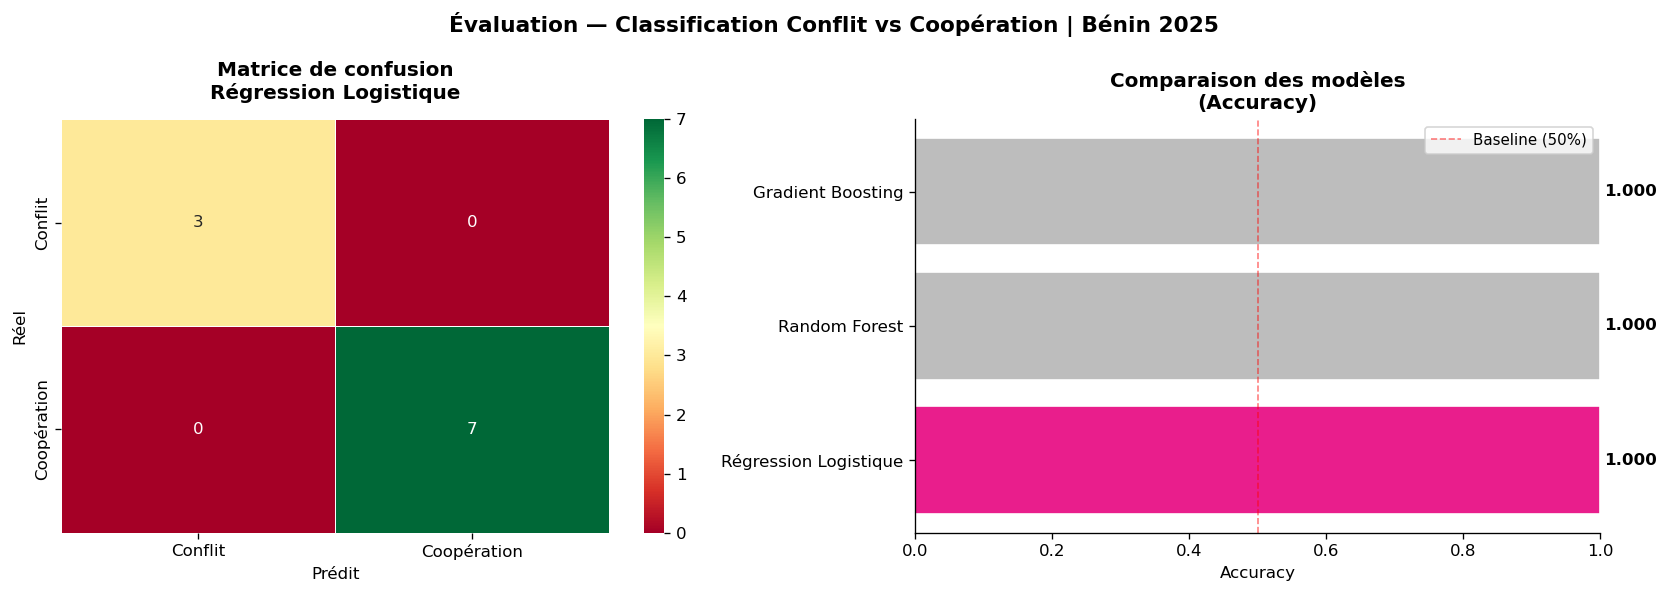

In [40]:
# ── Rapport complet du meilleur modèle ─────────────────────────
print(f"\n{'='*55}")
print(f"📊 RAPPORT DÉTAILLÉ — {meilleur}")
print(f"{'='*55}\n")

y_pred_best = resultats[meilleur]['y_pred']
print(classification_report(y_test, y_pred_best,
                            target_names=['Conflit','Coopération'],
                            digits=3))

# ── Matrice de confusion ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred_best, labels=['Conflit','Coopération'])
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn',
            xticklabels=['Conflit','Coopération'],
            yticklabels=['Conflit','Coopération'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title(f'Matrice de confusion\n{meilleur}',
                  fontweight='bold', pad=12)
axes[0].set_ylabel('Réel'); axes[0].set_xlabel('Prédit')

# ── Comparaison des accuracies ──────────────────────────────────
noms   = list(resultats.keys())
scores = [resultats[n]['accuracy'] for n in noms]
colors = ['#E91E8C' if n == meilleur else '#BDBDBD' for n in noms]

bars = axes[1].barh(noms, scores, color=colors, edgecolor='white')
axes[1].set_xlim(0, 1)
axes[1].axvline(0.5, color='red', linewidth=1,
                linestyle='--', alpha=0.5, label='Baseline (50%)')
for bar, score in zip(bars, scores):
    axes[1].text(score + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{score:.3f}', va='center', fontweight='bold')
axes[1].set_title('Comparaison des modèles\n(Accuracy)', fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('Évaluation — Classification Conflit vs Coopération | Bénin 2025',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_evaluation.png', bbox_inches='tight')
plt.show()

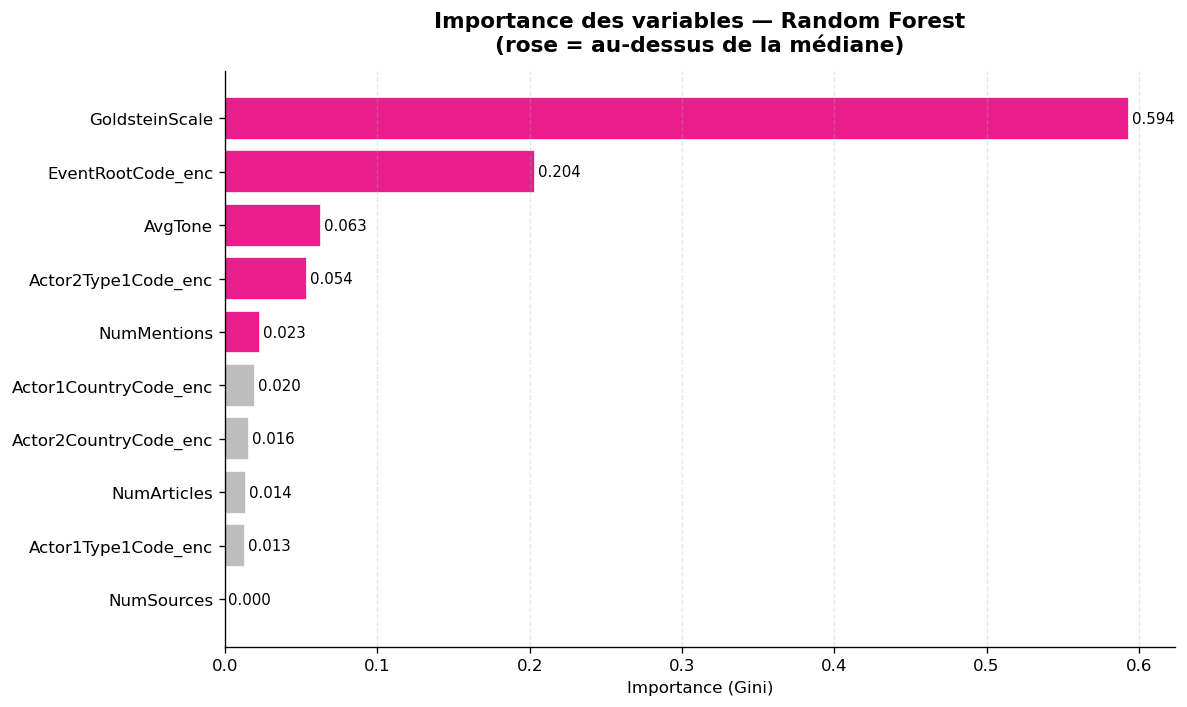


💡 Top 3 variables les plus discriminantes :
   1. GoldsteinScale                 → 0.594
   2. EventRootCode_enc              → 0.204
   3. AvgTone                        → 0.063


In [41]:
# ── Utiliser Random Forest pour l'importance des variables ─────
rf = resultats['Random Forest']['modele']
importances = pd.Series(rf.feature_importances_, index=features_num)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors_imp = ['#E91E8C' if v > importances.median()
              else '#BDBDBD' for v in importances.values]
bars = ax.barh(importances.index, importances.values,
               color=colors_imp, edgecolor='white')

# Annotations
for bar, val in zip(bars, importances.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_title('Importance des variables — Random Forest\n'
             '(rose = au-dessus de la médiane)',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Importance (Gini)')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print("\n💡 Top 3 variables les plus discriminantes :")
top3 = importances.tail(3)[::-1]
for i, (feat, score) in enumerate(top3.items(), 1):
    print(f"   {i}. {feat:<30} → {score:.3f}")

In [42]:
import joblib
import os
os.makedirs('models', exist_ok=True)

# Sauvegarder le meilleur modèle + le scaler
joblib.dump(resultats[meilleur]['modele'], 'models/meilleur_modele.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(features_num, 'models/features.pkl')

# Sauvegarder les prédictions pour le rapport
df_resultats = X_test.copy()
df_resultats['reel']  = y_test.values
df_resultats['predit'] = y_pred_best
df_resultats['correct'] = df_resultats['reel'] == df_resultats['predit']
df_resultats.to_csv('data/predictions_test.csv', index=False)

print("✅ Modèle sauvegardé → models/meilleur_modele.pkl")
print("✅ Scaler sauvegardé → models/scaler.pkl")
print("✅ Prédictions       → data/predictions_test.csv")
print("\n📋 Résumé final pour le rapport :")
print(f"   Modèle retenu    : {meilleur}")
print(f"   Accuracy         : {resultats[meilleur]['accuracy']*100:.1f}%")
print(f"   Features         : {len(features_num)} variables")
print(f"   Train size       : {len(X_train):,} événements")
print(f"   Test size        : {len(X_test):,} événements")
print(f"\n🎯 Fichiers générés pour le hackathon :")
print("   model_evaluation.png")
print("   feature_importance.png")
print("   models/meilleur_modele.pkl")

✅ Modèle sauvegardé → models/meilleur_modele.pkl
✅ Scaler sauvegardé → models/scaler.pkl
✅ Prédictions       → data/predictions_test.csv

📋 Résumé final pour le rapport :
   Modèle retenu    : Régression Logistique
   Accuracy         : 100.0%
   Features         : 10 variables
   Train size       : 37 événements
   Test size        : 10 événements

🎯 Fichiers générés pour le hackathon :
   model_evaluation.png
   feature_importance.png
   models/meilleur_modele.pkl
